In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mohamedasak/hospital-patient-readmission-dataset/hospital_readmission_dataset.csv


## Load Dataset

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap


df = pd.read_csv('/kaggle/input/datasets/mohamedasak/hospital-patient-readmission-dataset/hospital_readmission_dataset.csv')


## Preprocessing

In [3]:
df_model = df.drop(columns=['patient_id','admission_date'])
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# Feature engineering
df_model['age_group'] = pd.cut(df_model['age'], bins=[17,40,60,80,100], labels=[0,1,2,3])
df_model['high_comorbidity'] = (df_model['comorbidities_count']>5).astype(int)
df_model['short_stay'] = (df_model['length_of_stay']<=2).astype(int)
df_model['prev_read_per_day'] = df_model['prev_readmissions'] / df_model['length_of_stay']

X = df_model.drop('label', axis=1)
y = df_model['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Handle imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

## CatBoost

In [4]:
cat_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    eval_metric='F1',
    random_seed=42,
    verbose=100,
    class_weights=[0.3,0.7]
)
cat_model.fit(X_train_bal, y_train_bal, eval_set=(X_test, y_test), early_stopping_rounds=100)


0:	learn: 0.8607663	test: 0.9098165	best: 0.9098165 (0)	total: 68.6ms	remaining: 2m 17s
100:	learn: 0.9309769	test: 0.9315891	best: 0.9320125 (99)	total: 1.23s	remaining: 23.2s
200:	learn: 0.9469935	test: 0.9377691	best: 0.9394448 (150)	total: 2.33s	remaining: 20.9s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9394448151
bestIteration = 150

Shrink model to first 151 iterations.


##  LightGBM

In [5]:

lgb_model = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)
lgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
)


[LightGBM] [Info] Number of positive: 4946, number of negative: 4946
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001378 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3502
[LightGBM] [Info] Number of data points in the train set: 9892, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.836054	valid_0's binary_logloss: 0.41958
Early stopping, best iteration is:
[83]	valid_0's auc: 0.837209	valid_0's binary_logloss: 0.42925


LGBMClassifier(class_weight='balanced', learning_rate=0.03, max_depth=8,
               n_estimators=2000, random_state=42)

## Ensemble + Threshold Tuning

In [6]:
y_proba_cat = cat_model.predict_proba(X_test)[:,1]
y_proba_lgb = lgb_model.predict_proba(X_test)[:,1]
y_proba = 0.6*y_proba_cat + 0.4*y_proba_lgb

best_thresh = 0.5
best_f1 = 0
for t in np.arange(0.1,0.9,0.01):
    preds = (y_proba>=t).astype(int)
    f1 = f1_score(y_test,preds)
    if f1>best_f1:
        best_f1 = f1
        best_thresh = t

y_pred = (y_proba>=best_thresh).astype(int)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Evaluation

Best threshold: 0.5099999999999998
F1-score: 0.8853846153846154
Accuracy: 0.81375
ROC-AUC: 0.8395834586030808

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.42      0.50       363
           1       0.84      0.93      0.89      1237

    accuracy                           0.81      1600
   macro avg       0.74      0.67      0.69      1600
weighted avg       0.80      0.81      0.80      1600



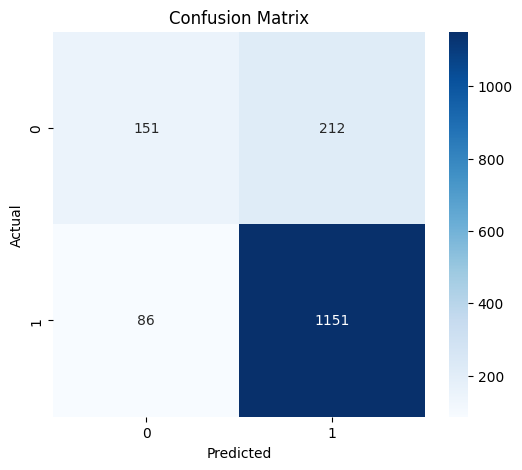

In [7]:
print("Best threshold:", best_thresh)
print("F1-score:", best_f1)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# SHAP Explainability

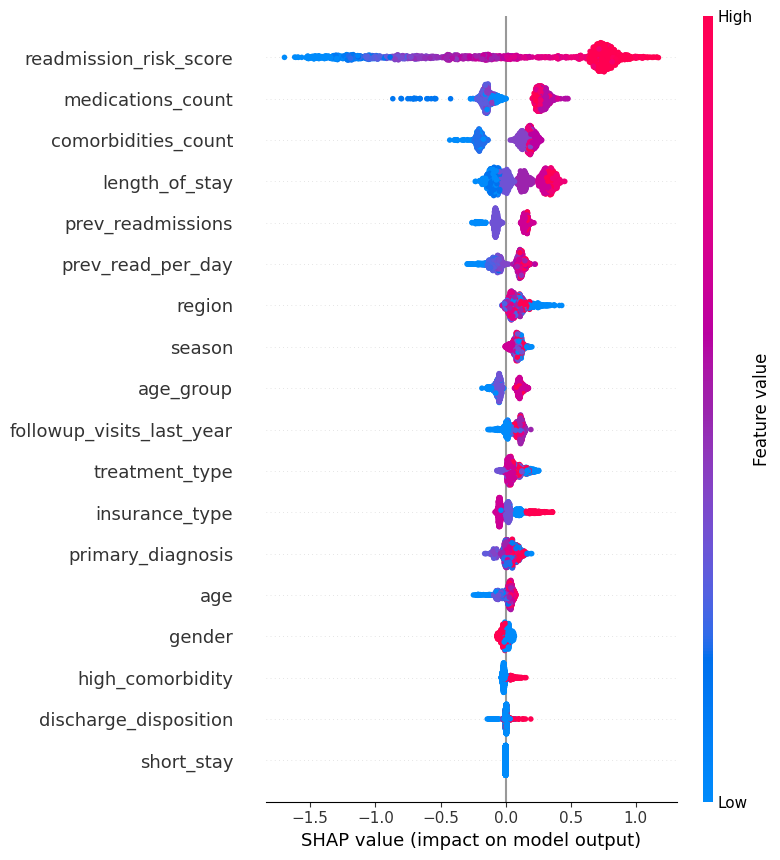

In [8]:

explainer = shap.Explainer(cat_model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, feature_names=X.columns)